In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance

In [ ]:
sns.set_style("whitegrid")
# Load the dataset
file_path = 'heart_disease_uci.csv'
df = pd.read_csv(file_path)

# Display the first 10 rows of dataset
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [ ]:
# original 16 column names
print("Original 16 column names:")
print(df.columns)

# We are dropping 'id' and 'dataset' which are not useful for prediction.
columns_to_keep = ['age','sex','cp','trestbps','chol','fbs','restecg',
                  'thalch','exang','oldpeak','slope','ca','thal','num']
df = df[columns_to_keep]
print(f"\nDataset shape after selecting 14 columns: {df.shape}")

# renaming columns for clarity
df.columns = ['age','sex','chest_pain_type','resting_blood_pressure','cholesterol','fasting_blood_sugar',
              'rest_ecg','max_heart_rate','exercise_induced_angina','st_depression','st_slope',
              'num_major_vessels','thalassemia','target']
print("\nDataset columns after renaming:")
print(df.columns)

# The target column  has values 0,1,2,3,4
# 0 means no disease. 1,2,3,4 mean varying degrees of disease
# We need to convert this into a binary problem: 0 (no disease) vs 1 (has disease)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
print("\nValue counts of the binary target variable:")
print(df['target'].value_counts())

# check for missing values and duplicates
df.replace('?',np.nan,inplace=True)
 # drop rows with any missing values
df.dropna(inplace=True)
print("\nData types after cleaning:")
df.info()
print(f"\nfinal dataset shape after all cleaning: {df.shape}")

Original 16 column names:
Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

Dataset shape after selecting 14 columns: (920, 14)

Dataset columns after renaming:
Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate',
       'exercise_induced_angina', 'st_depression', 'st_slope',
       'num_major_vessels', 'thalassemia', 'target'],
      dtype='object')

Value counts of the binary target variable:
target
1    509
0    411
Name: count, dtype: int64

Data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 748
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      299 non-null    int64  
 1   sex                      299 non-null    obje

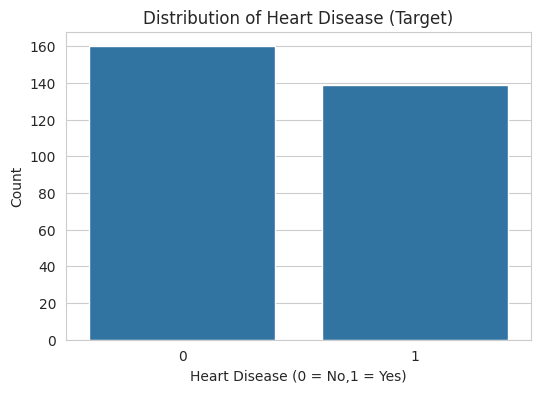

target
0    160
1    139
Name: count, dtype: int64


In [ ]:
# Visualize the distribution of the target variable
plt.figure(figsize=(6,4))
sns.countplot(x='target',data=df)
plt.title('Distribution of Heart Disease (Target)')
plt.xlabel('Heart Disease (0 = No,1 = Yes)')
plt.ylabel('Count')
plt.show()

# Print the exact counts
print(df['target'].value_counts())

In [ ]:
df_encoded = pd.get_dummies(df,drop_first=True)
print("DataFrame columns after one-hot encoding:")
print(df_encoded.columns)

print("First 10 rows of the new encoded dataframe:")
df_encoded.head(10)

DataFrame columns after one-hot encoding:
Index(['age', 'resting_blood_pressure', 'cholesterol', 'max_heart_rate',
       'st_depression', 'num_major_vessels', 'target', 'sex_Male',
       'chest_pain_type_atypical angina', 'chest_pain_type_non-anginal',
       'chest_pain_type_typical angina', 'fasting_blood_sugar_True',
       'rest_ecg_normal', 'rest_ecg_st-t abnormality',
       'exercise_induced_angina_True', 'st_slope_flat', 'st_slope_upsloping',
       'thalassemia_normal', 'thalassemia_reversable defect'],
      dtype='object')
First 10 rows of the new encoded dataframe:


,age,resting_blood_pressure,cholesterol,max_heart_rate,st_depression,num_major_vessels,target,sex_Male,chest_pain_type_atypical angina,chest_pain_type_non-anginal,chest_pain_type_typical angina,fasting_blood_sugar_True,rest_ecg_normal,rest_ecg_st-t abnormality,exercise_induced_angina_True,st_slope_flat,st_slope_upsloping,thalassemia_normal,thalassemia_reversable defect
0,63,145.0,233.0,150.0,2.3,0.0,0,True,False,False,True,True,False,False,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,3.0,1,True,False,False,False,False,False,False,True,True,False,True,False
2,67,120.0,229.0,129.0,2.6,2.0,1,True,False,False,False,False,False,False,True,True,False,False,True
3,37,130.0,250.0,187.0,3.5,0.0,0,True,False,True,False,False,True,False,False,False,False,True,False
4,41,130.0,204.0,172.0,1.4,0.0,0,False,True,False,False,False,False,False,False,False,True,True,False
5,56,120.0,236.0,178.0,0.8,0.0,0,True,True,False,False,False,True,False,False,False,True,True,False
6,62,140.0,268.0,160.0,3.6,2.0,1,False,False,False,False,False,False,False,False,False,False,True,False
7,57,120.0,354.0,163.0,0.6,0.0,0,False,False,False,False,False,True,False,True,False,True,True,False
8,63,130.0,254.0,147.0,1.4,1.0,1,True,False,False,False,False,False,False,False,True,False,False,True
9,53,140.0,203.0,155.0,3.1,0.0,1,True,False,False,False,True,False,False,True,False,False,False,True


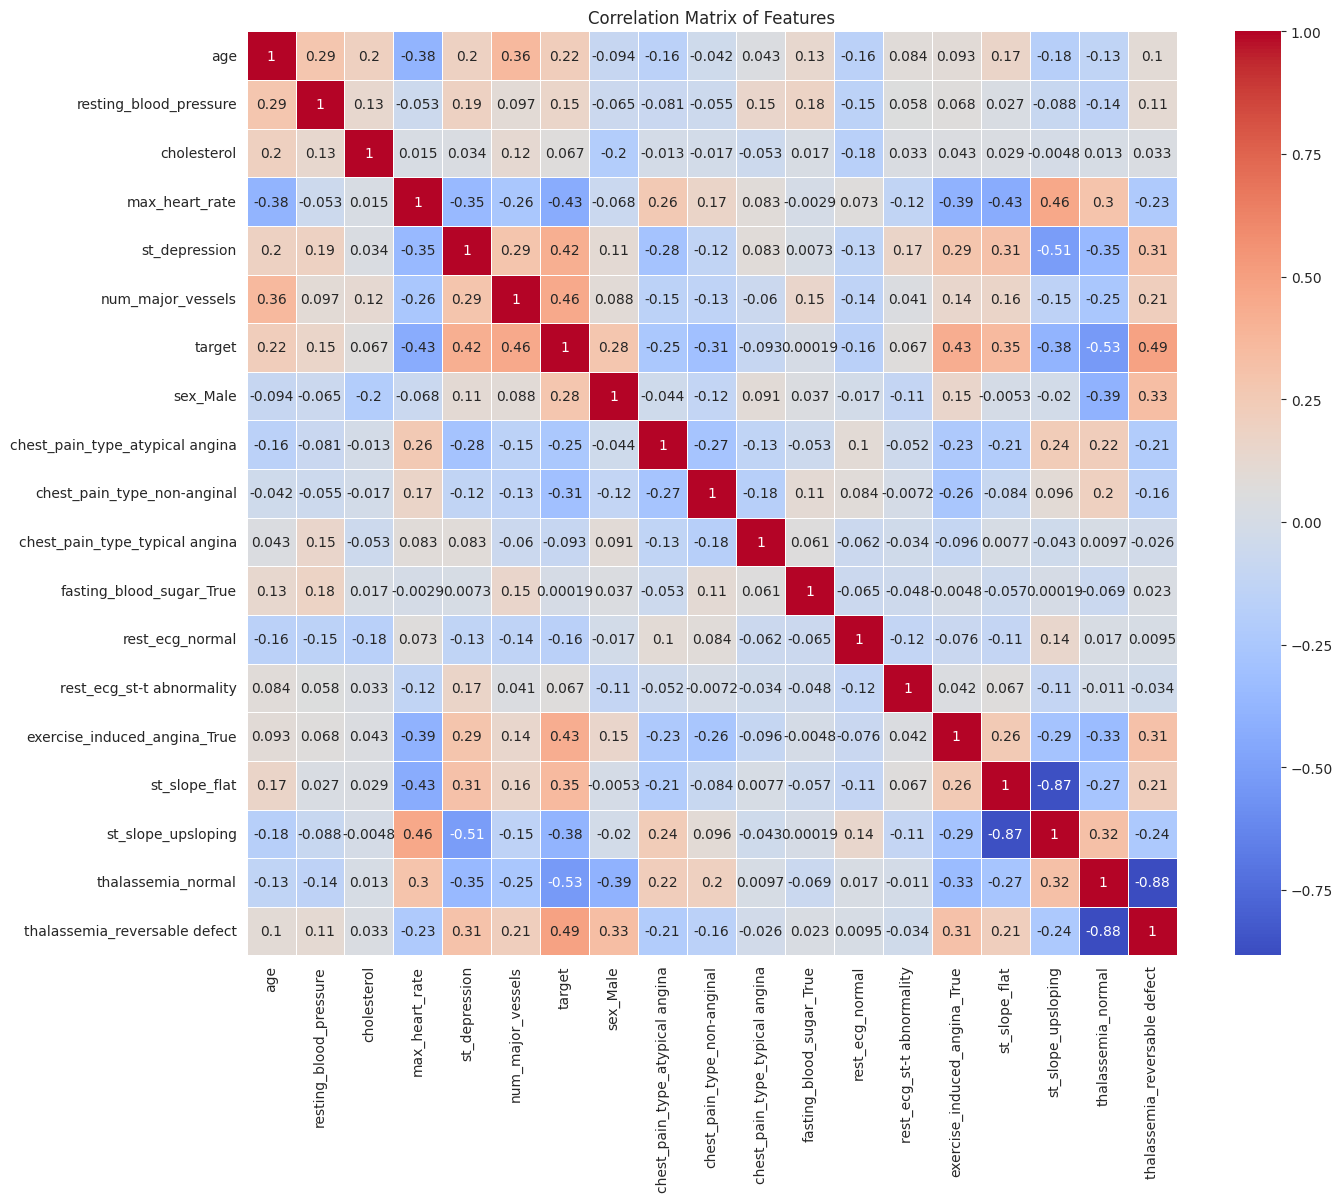

In [ ]:
# creating the correlation matrix
plt.figure(figsize=(15,12))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

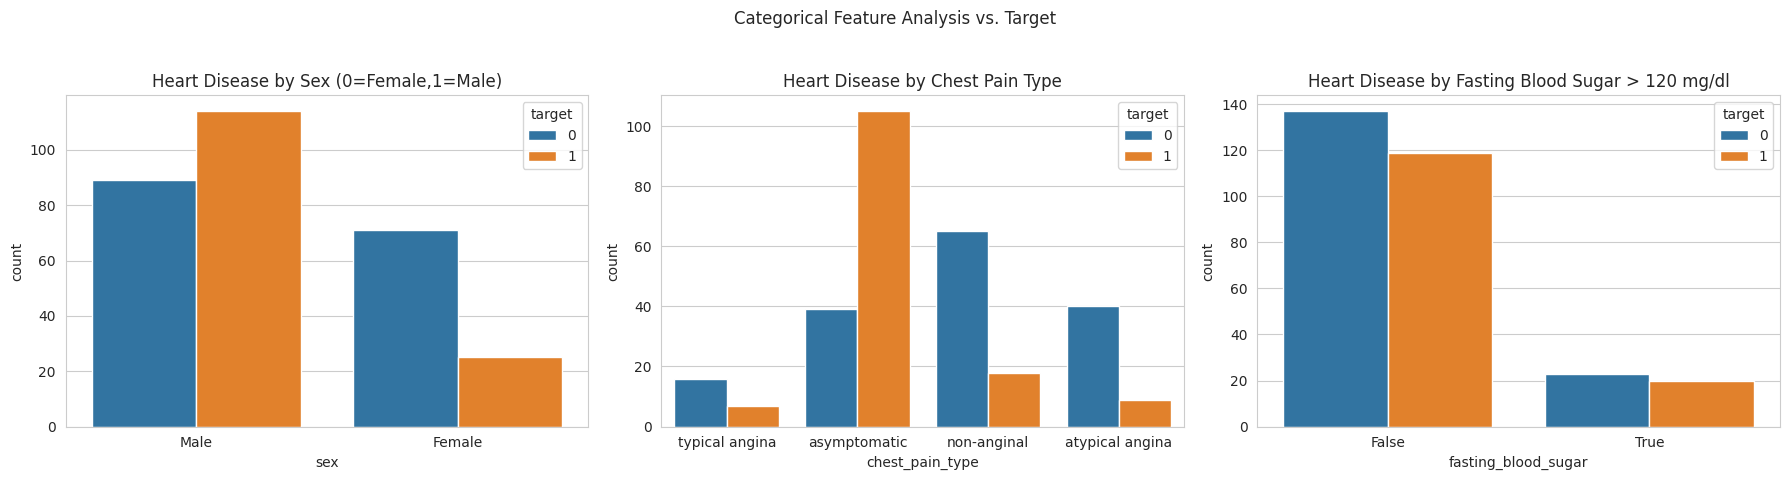

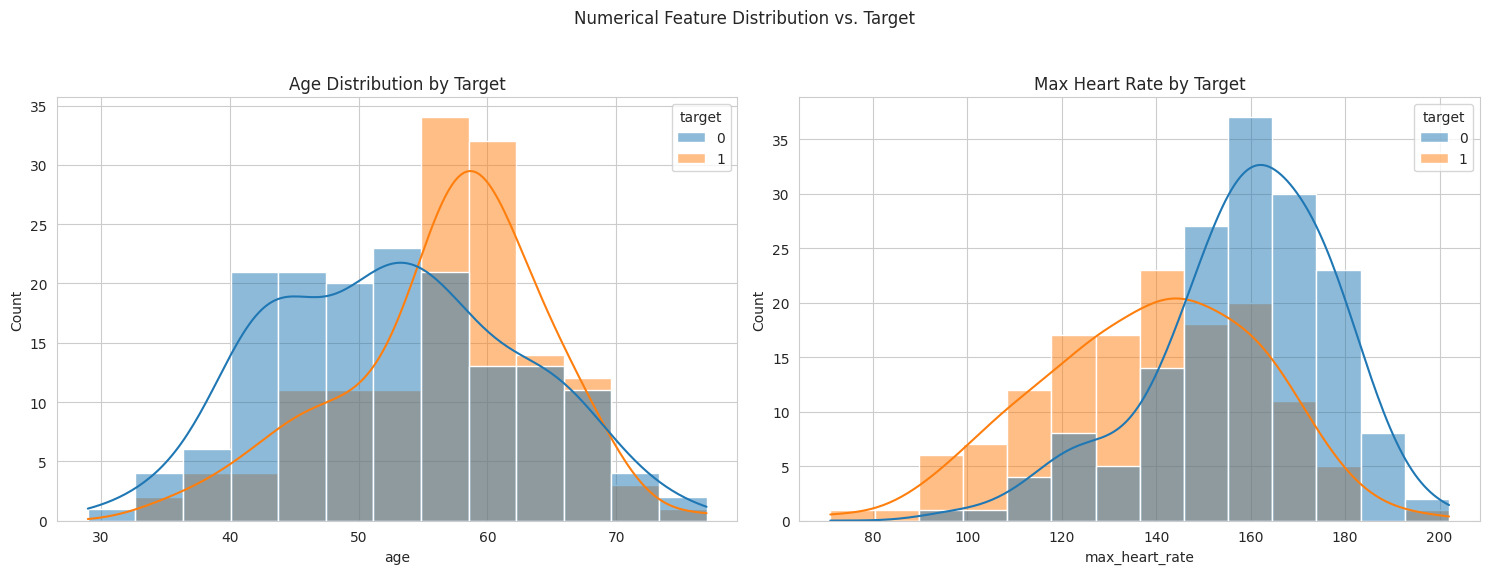

In [ ]:
# Analyzing categorical features
fig,axes = plt.subplots(1,3,figsize=(18,5))
fig.suptitle('Categorical Feature Analysis vs. Target')

sns.countplot(ax=axes[0],x='sex',data=df,hue='target')
axes[0].set_title('Heart Disease by Sex (0=Female,1=Male)')
sns.countplot(ax=axes[1],x='chest_pain_type',data=df,hue='target')
axes[1].set_title('Heart Disease by Chest Pain Type')
sns.countplot(ax=axes[2],x='fasting_blood_sugar',data=df,hue='target')
axes[2].set_title('Heart Disease by Fasting Blood Sugar > 120 mg/dl')
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

# Analyzing numerical features
fig,axes = plt.subplots(1,2,figsize=(15,6))
fig.suptitle('Numerical Feature Distribution vs. Target')

sns.histplot(ax=axes[0],data=df,x='age',hue='target',kde=True)
axes[0].set_title('Age Distribution by Target')
sns.histplot(ax=axes[1],data=df,x='max_heart_rate',hue='target',kde=True)
axes[1].set_title('Max Heart Rate by Target')
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

In [ ]:
# preparing the data for modeling using the encoded dataframe
X = df_encoded.drop('target',axis=1)
y = df_encoded['target']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (239, 18)
Shape of X_test: (60, 18)


In [ ]:
# Initializing and training the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

Model Accuracy: 0.8167
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84        32
           1       0.87      0.71      0.78        28

    accuracy                           0.82        60
   macro avg       0.83      0.81      0.81        60
weighted avg       0.82      0.82      0.81        60


Confusion Matrix:


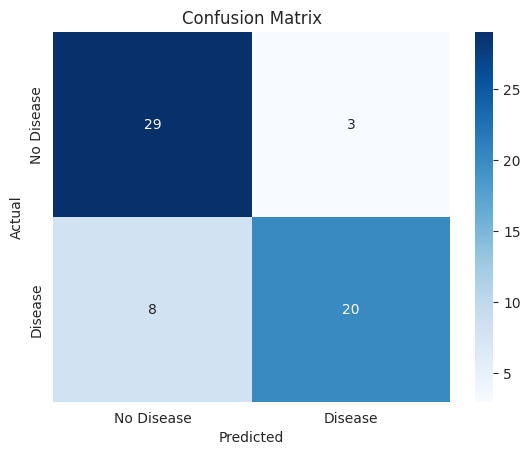

In [ ]:
# Model performance on the test set
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test,y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Classification report
print("Classification Report:")
print(classification_report(y_test,y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['No Disease','Disease'],yticklabels=['No Disease','Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

/tmp/ipython-input-3054465715.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance_mean',y='feature',data=perm_importance,palette='viridis')


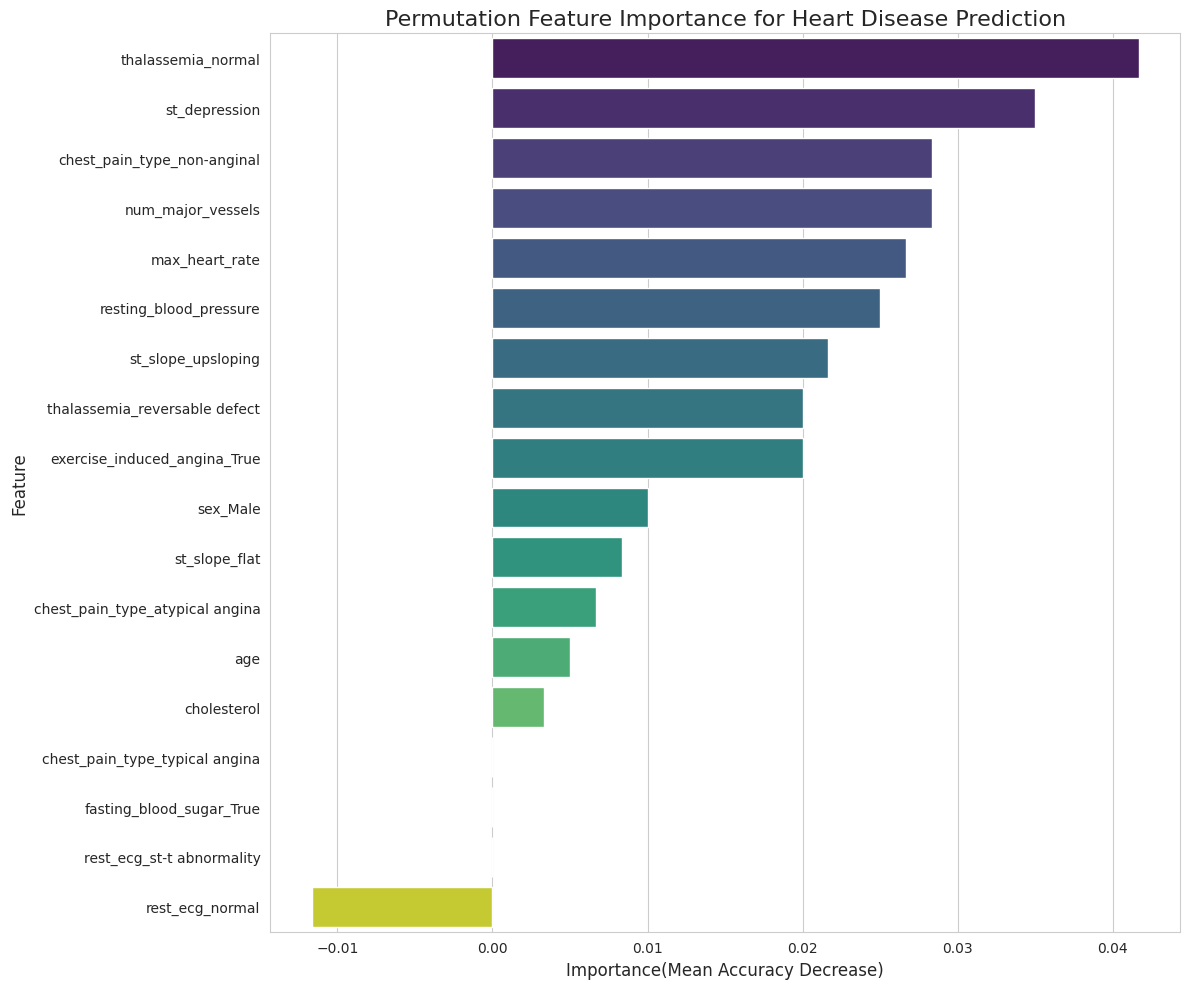

In [ ]:
# Applying Permutation Importance to explain the model
result = permutation_importance(model,X_test,y_test,n_repeats=10,random_state=42,n_jobs=-1)
perm_importance = pd.DataFrame({'feature': X.columns,'importance_mean': result.importances_mean})
perm_importance = perm_importance.sort_values('importance_mean',ascending=False)

plt.figure(figsize=(12,10))
sns.barplot(x='importance_mean',y='feature',data=perm_importance,palette='viridis')
plt.title('Permutation Feature Importance for Heart Disease Prediction',fontsize=16)
plt.xlabel('Importance(Mean Accuracy Decrease)',fontsize=12)
plt.ylabel('Feature',fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Print the top 10 most important features
print("\nTop 10 most important features according to the model:")
perm_importance.head(10)


Top 10 most important features according to the model:


,feature,importance_mean
16,thalassemia_normal,0.041667
4,st_depression,0.035000
8,chest_pain_type_non-anginal,0.028333
5,num_major_vessels,0.028333
3,max_heart_rate,0.026667
1,resting_blood_pressure,0.025000
15,st_slope_upsloping,0.021667
17,thalassemia_reversable defect,0.020000
13,exercise_induced_angina_True,0.020000
6,sex_Male,0.010000


Partial dependence plots for the Top Features
Plotting the top 3 most suitable features for PDP: ['st_depression', 'num_major_vessels', 'max_heart_rate']


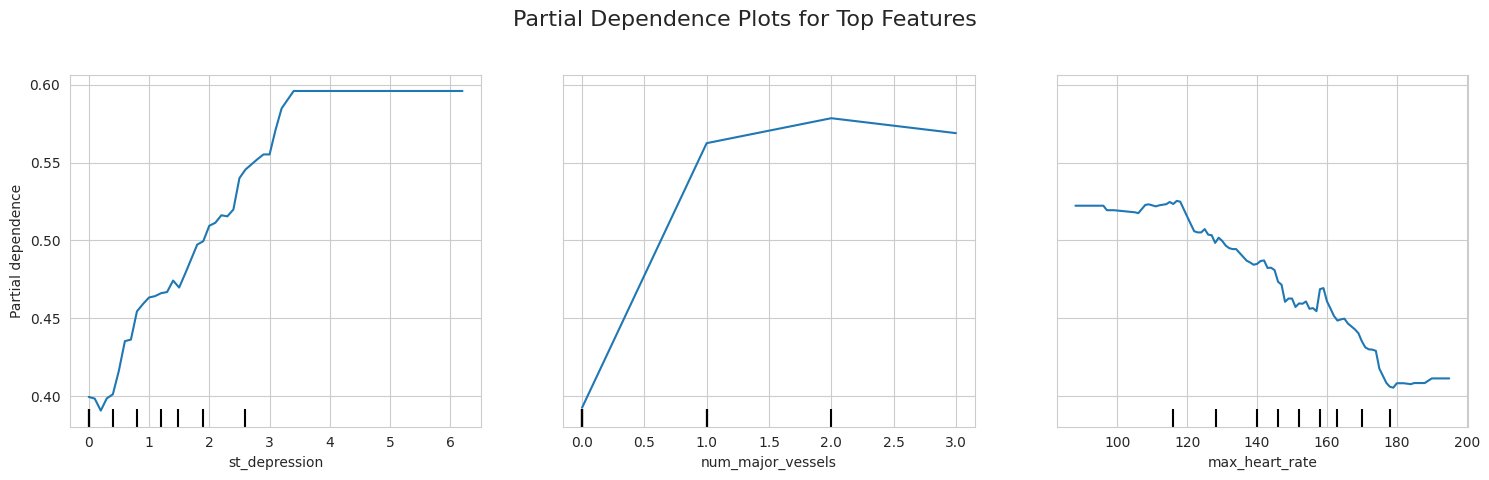

In [ ]:
print("Partial dependence plots for the Top Features")
# Intelligent Feature Selection :
# PDPs are most insightful for continuous features
all_features = perm_importance['feature'].tolist()
features_to_plot_1d = []
for feature in all_features:
    if ('_' not in feature or feature in ['st_depression','st_slope','max_heart_rate','resting_blood_pressure','num_major_vessels']):
        features_to_plot_1d.append(feature)
    if len(features_to_plot_1d) == 3:
        break

print(f"Plotting the top 3 most suitable features for PDP: {features_to_plot_1d}")
display = PartialDependenceDisplay.from_estimator(model,X_train,features_to_plot_1d,n_cols=3)
display.figure_.set_figwidth(15)
display.figure_.set_figheight(5)
display.figure_.suptitle("Partial Dependence Plots for Top Features",fontsize=16)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


Plotting the interaction between: st_depression and num_major_vessels


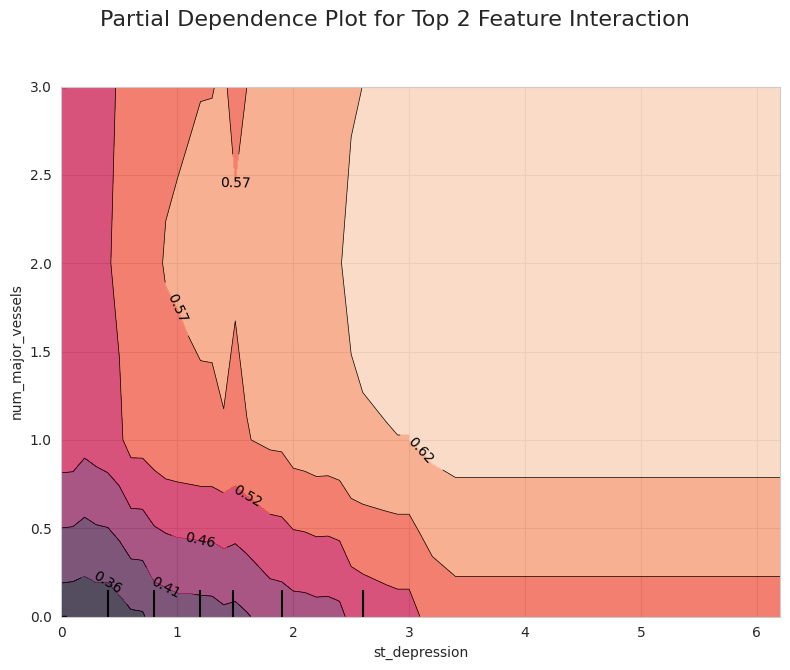

In [ ]:
# For interaction plot, we will pick the top two most suitable features from our new list
interaction_features_2d = [(features_to_plot_1d[0], features_to_plot_1d[1])]
print(f"\nPlotting the interaction between: {features_to_plot_1d[0]} and {features_to_plot_1d[1]}")

display2 = PartialDependenceDisplay.from_estimator(model,X_train,interaction_features_2d)
display2.figure_.set_figwidth(8)
display2.figure_.set_figheight(7)
display2.figure_.suptitle("Partial Dependence Plot for Top 2 Feature Interaction", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()